# HelpDesk AI
## LSTM Seq2Seq chatbot with Bahdanau attention
This notebook implements the supplied project brief using its custom customer-support FAQ dataset option. The dataset is synthetic. The included outputs come from a real CPU training run. Read the model card before interpreting the scores.

In [1]:
from pathlib import Path
import os, sys
ROOT = Path.cwd()
if not (ROOT / 'helpdesk').exists():
    ROOT = ROOT.parent
assert (ROOT / 'helpdesk').exists(), 'Open this notebook from the project or notebooks folder'
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
import json
import torch
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
torch.set_num_threads(2)
print('PyTorch:', torch.__version__)


PyTorch: 2.14.0+cpu


## 1. Dataset and preprocessing
Lowercase the text, remove non-alphanumeric symbols, and retain at most 15 words. Split distinct normalized prompts before vocabulary construction. Similar paraphrases can still occur across splits; this is a small in-domain demonstration.

In [2]:
"""Clean dialogue, split before building vocabulary, and pad minibatches."""
import re
from collections import Counter
import pandas as pd
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset

PAD, SOS, EOS, UNK = 0, 1, 2, 3
SPECIAL = ['<PAD>', '<SOS>', '<EOS>', '<UNK>']

def clean(text, max_words=15):
    return ' '.join(re.sub(r'[^a-z0-9\s]', ' ', str(text).lower()).split()[:max_words])

class Vocabulary:
    def __init__(self, words=None):
        self.words = words or SPECIAL.copy()
        self.ids = {w: i for i, w in enumerate(self.words)}

    @classmethod
    def build(cls, texts, min_frequency=1):
        counts = Counter(w for text in texts for w in text.split())
        return cls(SPECIAL + sorted(w for w, n in counts.items() if n >= min_frequency))

    def encode(self, text):
        return [self.ids.get(w, UNK) for w in text.split()] + [EOS]

    def __len__(self):
        return len(self.words)

def load_pairs(path, max_words=15):
    frame = pd.read_csv(path).dropna(subset=['question', 'answer'])
    for column in ['question', 'answer']:
        frame[column] = frame[column].map(lambda x: clean(x, max_words))
    frame = frame[(frame.question != '') & (frame.answer != '')]
    # Avoid identical normalized prompts crossing splits.
    frame = frame.drop_duplicates('question').reset_index(drop=True)
    if len(frame) < 20:
        raise ValueError('Provide at least 20 distinct, nonempty question/answer pairs.')
    return frame

def split_pairs(frame, seed=42):
    shuffled = frame.sample(frac=1, random_state=seed).reset_index(drop=True)
    n = len(shuffled)
    a, b = int(n * .8), int(n * .9)
    return shuffled.iloc[:a].copy(), shuffled.iloc[a:b].copy(), shuffled.iloc[b:].copy()

class Pairs(Dataset):
    def __init__(self, frame, vocab):
        self.items = [(torch.tensor(vocab.encode(q)), torch.tensor(vocab.encode(a)))
                      for q, a in zip(frame.question, frame.answer)]
    def __len__(self):
        return len(self.items)
    def __getitem__(self, i):
        return self.items[i]

def collate(batch):
    source, target = zip(*batch)
    lengths = torch.tensor([len(s) for s in source])
    return (pad_sequence(source, batch_first=True, padding_value=PAD), lengths,
            pad_sequence(target, batch_first=True, padding_value=PAD))


In [3]:
pairs = load_pairs('data/support_faq.csv')
train_df, val_df, test_df = split_pairs(pairs)
vocab = Vocabulary.build(list(train_df.question) + list(train_df.answer))
display(pairs.head())
print('Train / validation / test:', len(train_df), len(val_df), len(test_df))
print('Vocabulary size:', len(vocab))
print('Special tokens:', vocab.words[:4])
batch = collate([Pairs(train_df, vocab)[0], Pairs(train_df, vocab)[1]])
print('Padded source IDs:', batch[0])
print('Original lengths:', batch[1])
print('Padded targets including EOS:', batch[2])

Train / validation / test: 192 24 24
Vocabulary size: 268
Special tokens: ['<PAD>', '<SOS>', '<EOS>', '<UNK>']
Padded source IDs: tensor([[259,  18, 265,   2],
        [105, 234,   2,   0]])
Original lengths: tensor([4, 3])
Padded targets including EOS: tensor([[109,  12, 102,  11, 266, 219,  20,   2],
        [100, 108,  33, 109, 101, 265, 236,   2]])


,question,answer,topic
0,hi,hello how can i help you today,greeting
1,hello,hello how can i help you today,greeting
2,hey,hello how can i help you today,greeting
3,good morning,hello how can i help you today,greeting
4,good evening,hello how can i help you today,greeting


## 2. Architecture
The encoder and decoder are LSTMs. The decoder starts from the final encoder hidden and cell states. Bahdanau attention builds a context at each decoding step. Padding is excluded before softmax.

$$e_{t,i}=v^T\tanh(W_q s_{t-1}+W_k h_i),\quad \alpha_t=\operatorname{softmax}(e_t),\quad c_t=\sum_i\alpha_{t,i}h_i$$

The following cell contains the complete architecture implementation.

In [4]:
"""Explicit encoder, Bahdanau attention, and autoregressive LSTM decoder."""
import torch
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from helpdesk.data import PAD, SOS

class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=PAD)
        self.dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)

    def forward(self, source, lengths):
        embedded = self.dropout(self.embedding(source))
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        outputs, state = self.lstm(packed)
        outputs, _ = pad_packed_sequence(outputs, batch_first=True, total_length=source.size(1))
        return outputs, state

class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.query = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.key = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.score = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, query, keys, mask):
        # e_ti = v^T tanh(W_h h_i + W_s s_t)
        scores = self.score(torch.tanh(self.query(query).unsqueeze(1) + self.key(keys))).squeeze(-1)
        weights = scores.masked_fill(~mask, float('-inf')).softmax(dim=-1)
        context = torch.bmm(weights.unsqueeze(1), keys).squeeze(1)
        return context, weights

class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=PAD)
        self.dropout = nn.Dropout(dropout)
        self.attention = BahdanauAttention(hidden_dim)
        self.lstm = nn.LSTM(embedding_dim + hidden_dim, hidden_dim, batch_first=True)
        self.output = nn.Linear(hidden_dim * 2, vocab_size)

    def forward(self, token, state, encoder_outputs, mask):
        context, weights = self.attention(state[0][-1], encoder_outputs, mask)
        inputs = torch.cat([self.dropout(self.embedding(token)), context], dim=-1).unsqueeze(1)
        result, state = self.lstm(inputs, state)
        logits = self.output(torch.cat([result.squeeze(1), context], dim=-1))
        return logits, state, weights

class Seq2Seq(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=128, dropout=.15):
        super().__init__()
        self.encoder = Encoder(vocab_size, embedding_dim, hidden_dim, dropout)
        self.decoder = Decoder(vocab_size, embedding_dim, hidden_dim, dropout)

    def forward(self, source, lengths, target, teacher_forcing=1.0):
        outputs, state = self.encoder(source, lengths)
        mask = source.ne(PAD)
        token = torch.full((source.size(0),), SOS, device=source.device, dtype=torch.long)
        logits = []
        for t in range(target.size(1)):
            step, state, _ = self.decoder(token, state, outputs, mask)
            logits.append(step)
            use_truth = torch.rand(source.size(0), device=source.device) < teacher_forcing
            token = torch.where(use_truth, target[:, t], step.argmax(-1))
        return torch.stack(logits, dim=1)


In [5]:
example_model = Seq2Seq(len(vocab))
print(example_model)
print('Parameters:', sum(p.numel() for p in example_model.parameters()))
source, lengths, target = batch
print('Output shape [batch, target steps, vocabulary]:', example_model(source, lengths, target).shape)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(268, 64, padding_idx=0)
    (dropout): Dropout(p=0.15, inplace=False)
    (lstm): LSTM(64, 128, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(268, 64, padding_idx=0)
    (dropout): Dropout(p=0.15, inplace=False)
    (attention): BahdanauAttention(
      (query): Linear(in_features=128, out_features=128, bias=False)
      (key): Linear(in_features=128, out_features=128, bias=False)
      (score): Linear(in_features=128, out_features=1, bias=False)
    )
    (lstm): LSTM(192, 128, batch_first=True)
    (output): Linear(in_features=256, out_features=268, bias=True)
  )
)
Parameters: 400268
Output shape [batch, target steps, vocabulary]: torch.Size([2, 8, 268])


## 3. Training logic
Cross-entropy ignores padding and is averaged over non-padding tokens. Teacher forcing decreases toward 0.5; dropout and gradient clipping stabilize training. The lowest validation-loss checkpoint is saved. The test set is used only after model selection. Validation and test perplexity use full teacher forcing; training loss uses the scheduled ratio.

In [6]:
"""Run from project root: python train.py --epochs 50."""
import argparse
import hashlib
import json
import math
import random
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader
from helpdesk.data import PAD, Vocabulary, load_pairs, split_pairs, Pairs, collate
from helpdesk.model import Seq2Seq


def token_loss(model, loader, device):
    model.eval()
    loss_sum, tokens = 0., 0
    criterion = nn.CrossEntropyLoss(ignore_index=PAD, reduction='sum')
    with torch.inference_mode():
        for source, lengths, target in loader:
            source, target = source.to(device), target.to(device)
            logits = model(source, lengths, target, teacher_forcing=1.)
            loss_sum += criterion(logits.flatten(0, 1), target.flatten()).item()
            tokens += target.ne(PAD).sum().item()
    return loss_sum / tokens


def train(data='data/support_faq.csv', output='artifacts', epochs=50, batch_size=32,
          embedding_dim=64, hidden_dim=128, lr=.003, dropout=.15, seed=42,
          max_words=15, patience=12, device='cpu'):
    if epochs < 1 or max_words < 1 or batch_size < 1:
        raise ValueError('epochs, max_words, and batch_size must be positive')
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.set_num_threads(2)
    out = Path(output)
    out.mkdir(parents=True, exist_ok=True)
    frame = load_pairs(data, max_words)
    train_df, val_df, test_df = split_pairs(frame, seed)
    vocab = Vocabulary.build(list(train_df.question) + list(train_df.answer))
    loaders = []
    for name, part in [('train', train_df), ('validation', val_df), ('test', test_df)]:
        part.to_csv(out / f'{name}.csv', index=False)
        loaders.append(DataLoader(Pairs(part, vocab), batch_size=batch_size,
                                  shuffle=(name == 'train'), collate_fn=collate))
    architecture = dict(embedding_dim=embedding_dim, hidden_dim=hidden_dim, dropout=dropout)
    config = dict(max_words=max_words, seed=seed, epochs_requested=epochs, batch_size=batch_size,
                  learning_rate=lr, patience=patience, data_sha256=hashlib.sha256(Path(data).read_bytes()).hexdigest())
    model = Seq2Seq(len(vocab), **architecture).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD, reduction='sum')
    best, bad_epochs, history = float('inf'), 0, []
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, count = 0., 0
        ratio = max(.5, 1 - .5 * (epoch - 1) / max(epochs - 1, 1))
        for source, lengths, target in loaders[0]:
            source, target = source.to(device), target.to(device)
            optimizer.zero_grad()
            logits = model(source, lengths, target, ratio)
            loss = criterion(logits.flatten(0, 1), target.flatten())
            n = target.ne(PAD).sum()
            (loss / n).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.)
            optimizer.step()
            total_loss += loss.item()
            count += n.item()
        val_loss = token_loss(model, loaders[1], device)
        history.append(dict(epoch=epoch, train_loss=total_loss/count, validation_loss=val_loss,
                            validation_perplexity=math.exp(min(val_loss, 30)), teacher_forcing=ratio))
        if val_loss < best - .0001:
            best, bad_epochs = val_loss, 0
            torch.save(dict(state_dict=model.state_dict(), vocabulary=vocab.words,
                            architecture=architecture, config=config, epoch=epoch,
                            validation_loss=val_loss), out / 'best.pt')
        else:
            bad_epochs += 1
        if epoch == 1 or epoch % 10 == 0:
            print(f'Epoch {epoch}: train={total_loss/count:.4f} validation={val_loss:.4f}', flush=True)
        if bad_epochs >= patience:
            print(f'Early stopping at epoch {epoch}', flush=True)
            break
    checkpoint = torch.load(out / 'best.pt', map_location=device, weights_only=True)
    model.load_state_dict(checkpoint['state_dict'])
    torch.save(model.encoder.state_dict(), out / 'encoder.pt')
    torch.save(model.decoder.state_dict(), out / 'decoder.pt')
    (out / 'vocabulary.json').write_text(json.dumps(vocab.words, indent=2), encoding='utf-8')
    (out / 'config.json').write_text(json.dumps(dict(config=config, architecture=architecture), indent=2))
    pd.DataFrame(history).to_csv(out / 'history.csv', index=False)
    test_loss = token_loss(model, loaders[2], device)
    report = dict(best_epoch=checkpoint['epoch'], epochs_completed=len(history),
                  training_pairs=len(train_df), validation_pairs=len(val_df), test_pairs=len(test_df),
                  vocabulary_size=len(vocab), validation_loss=best,
                  test_loss=test_loss, test_perplexity=math.exp(min(test_loss, 30)),
                  note='Synthetic FAQ demo; random prompt split includes related paraphrases. Not a production benchmark.')
    (out / 'metrics.json').write_text(json.dumps(report, indent=2))
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot([h['epoch'] for h in history], [h['train_loss'] for h in history], label='Train (scheduled teacher forcing)')
    ax.plot([h['epoch'] for h in history], [h['validation_loss'] for h in history], label='Validation (full teacher forcing)')
    ax.set(xlabel='Epoch', ylabel='Cross-entropy per non-padding token', title='HelpDesk AI | Actual training run')
    ax.legend()
    ax.grid(alpha=.2)
    fig.tight_layout()
    fig.savefig(out / 'loss.png', dpi=160)
    plt.close(fig)
    print(json.dumps(report, indent=2), flush=True)
    return report



,Value
best_epoch,21
epochs_completed,36
training_pairs,192
validation_pairs,24
test_pairs,24
vocabulary_size,268
validation_loss,0.544107
test_loss,0.525912
test_perplexity,1.692001
note,Synthetic FAQ demo; random prompt split includ...


,epoch,train_loss,validation_loss,validation_perplexity,teacher_forcing
31,32,0.020642,0.555886,1.743486,0.843434
32,33,0.019405,0.570202,1.768624,0.838384
33,34,0.018088,0.560316,1.751225,0.833333
34,35,0.017740,0.552793,1.738101,0.828283
35,36,0.016179,0.552415,1.737444,0.823232


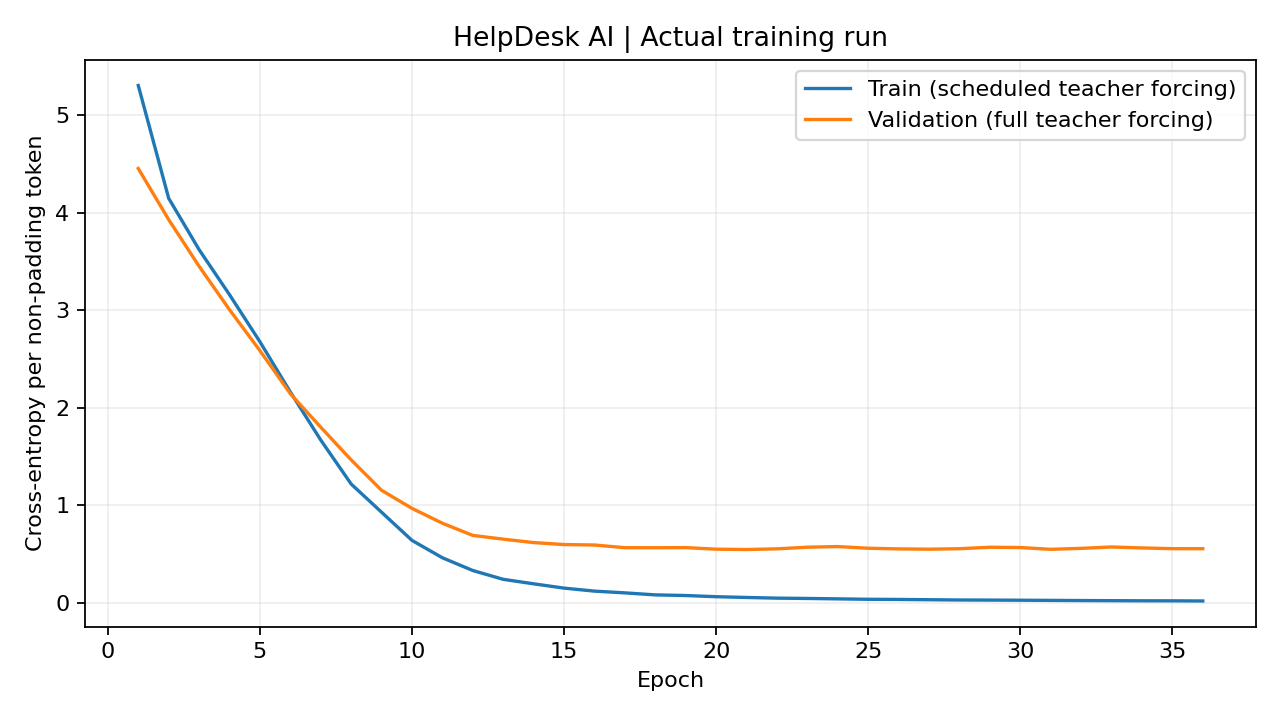

In [7]:
RUN_TRAINING = False  # Set True to rerun; this overwrites artifacts.
if RUN_TRAINING:
    train(epochs=100, patience=15)
metrics = json.loads(Path('artifacts/metrics.json').read_text())
display(pd.Series(metrics).to_frame('Value'))
history = pd.read_csv('artifacts/history.csv')
display(history.tail())
display(Image(filename='artifacts/loss.png'))

## 4. Inference
Begin with SOS, predict a token, feed it back, and stop at EOS or the length cap. Greedy decoding is required by the brief; beam search is an optional extension. This is neural generation, not FAQ lookup.

In [8]:
"""Greedy and length-normalized beam search. No FAQ retrieval or API replies."""
import math
from pathlib import Path
import torch
from helpdesk.data import Vocabulary, clean, PAD, SOS, EOS, UNK
from helpdesk.model import Seq2Seq

class Chatbot:
    def __init__(self, directory='artifacts', device='cpu'):
        self.device = torch.device(device)
        self.bundle = torch.load(Path(directory) / 'best.pt', map_location=self.device, weights_only=True)
        self.vocab = Vocabulary(self.bundle['vocabulary'])
        self.config = self.bundle['config']
        self.model = Seq2Seq(len(self.vocab), **self.bundle['architecture']).to(self.device)
        self.model.load_state_dict(self.bundle['state_dict'])
        self.model.eval()

    @torch.inference_mode()
    def reply(self, text, beam_width=1):
        if beam_width not in (1, 3, 5):
            raise ValueError('beam_width must be 1, 3, or 5')
        normalized = clean(text, self.config['max_words'])
        if not normalized:
            return {'text': 'Please enter a question using letters or numbers.', 'attention': [],
                    'input_tokens': [], 'output_tokens': [], 'unknown_ratio': 0.0, 'ended': False}
        ids = self.vocab.encode(normalized)
        source = torch.tensor([ids], device=self.device)
        outputs, state = self.model.encoder(source, torch.tensor([len(ids)]))
        mask = source.ne(PAD)
        # Each candidate owns token history, recurrent state, log probability, attention.
        beams = [([SOS], state, 0., [])]
        rank = lambda b: b[2] / (((5 + len(b[0]) - 1) / 6) ** .6)
        for _ in range(self.config['max_words'] + 1):
            candidates = []
            for tokens, previous, score, attention in beams:
                if tokens[-1] == EOS:
                    candidates.append((tokens, previous, score, attention))
                    continue
                logits, next_state, weights = self.model.decoder(
                    torch.tensor([tokens[-1]], device=self.device), previous, outputs, mask)
                logits[0, [PAD, SOS, UNK]] = float('-inf')
                values, indices = logits.log_softmax(-1).topk(beam_width, dim=-1)
                for value, index in zip(values[0].tolist(), indices[0].tolist()):
                    candidates.append((tokens + [index], next_state, score + value,
                                       attention + [weights[0].cpu().tolist()]))
            beams = sorted(candidates, key=rank, reverse=True)[:beam_width]
            if all(b[0][-1] == EOS for b in beams):
                break
        tokens, _, score, attention = max(beams, key=rank)
        output = [self.vocab.words[t] for t in tokens[1:]]
        words = [w for w in output if w != '<EOS>']
        return {'text': ' '.join(words) or 'No response generated. Please rephrase.',
                'attention': attention, 'input_tokens': [self.vocab.words[i] for i in ids],
                'output_tokens': output, 'unknown_ratio': ids[:-1].count(UNK) / max(1, len(ids)-1),
                'ended': tokens[-1] == EOS,
                'token_score': math.exp(score / max(1, len(tokens)-1))}


In [9]:
bot = Chatbot('artifacts')
examples = ['hi', 'how do i reset my password', 'where is my invoice', 'invite a teammate']
for question in examples:
    print('You:', question)
    print('Bot:', bot.reply(question)['text'])
    print()

You: hi
Bot: hello how can i help you today

You: how do i reset my password
Bot: select forgot password on the login page to reset your password

You: where is my invoice
Bot: open billing history to download your invoice

You: invite a teammate
Bot: open team settings and send an invitation using their email



## 5. Attention visualization
Columns represent input tokens and rows represent output tokens. Weights sum to one in each row. These are attention weights, not explanations that prove correctness.

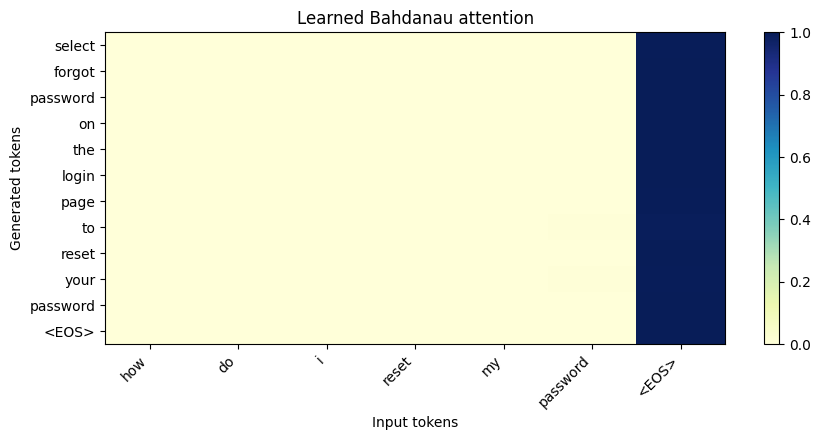

In [10]:
answer = bot.reply('how do i reset my password')
fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(answer['attention'], aspect='auto', cmap='YlGnBu', vmin=0, vmax=1)
ax.set_xticks(range(len(answer['input_tokens'])), answer['input_tokens'], rotation=45, ha='right')
ax.set_yticks(range(len(answer['output_tokens'])), answer['output_tokens'])
ax.set(xlabel='Input tokens', ylabel='Generated tokens', title='Learned Bahdanau attention')
fig.colorbar(im, ax=ax)
fig.tight_layout()
plt.show()

## 6. Held-out generation evaluation
Exact match is a strict comparison with one reference, not a complete measure of response quality. Compare failures and inspect unrelated questions. The split contains related paraphrases and cannot establish broad generalization.

In [11]:
from evaluate import evaluate
predictions = evaluate('artifacts')
display(predictions)
print('Greedy:', bot.reply('where is my invoice', 1)['text'])
print('Beam 3:', bot.reply('where is my invoice', 3)['text'])

{
  "exact_match": 0.5416666666666666,
  "eos_rate": 1.0,
  "examples": 24,
  "beam_width": 1,
  "note": "Exact match is strict; this tiny synthetic split does not measure real support quality."
}
Greedy: open billing history to download your invoice
Beam 3: open billing history to download your invoice


,question,reference,generated,exact_match,ended
0,website layout is broken,clear your browser cache and try opening the p...,clear your browser cache and try opening the p...,True,True
1,hello,hello how can i help you today,hello how can i help you today,True,True
2,i want to register,select sign up enter your details and verify y...,open preferences and choose your preferred lan...,False,True
3,where can i export data,open data settings and select export to downlo...,open data settings and select export to downlo...,True,True
4,where is verification email,check your inbox and spam folder for the verif...,check your inbox and spam folder for the verif...,True,True
5,save my account data,open data settings and select export to downlo...,open account settings and review the delete ac...,False,True
6,please return my payment,contact the support team to check refund eligi...,check your email and details try opening the,False,True
7,can i get a refund,contact the support team to check refund eligi...,open the help menu and select contact support,False,True
8,app closes suddenly,restart the app and install the latest update,restart the app and install the latest update,True,True
9,how to change plan,open subscription settings and choose the plan...,open subscription settings and choose the plan...,True,True


## 7. Launch the messaging interface
From the project folder run:
```bash
python -m streamlit run app.py
```
The UI includes a chat transcript, decoding controls, attention heatmaps, training dashboard, and JSON conversation export. It conditions on the current question only.

## References
- Supplied Persevex project brief, pages 2–4.
- [PyTorch Seq2Seq tutorial](https://docs.pytorch.org/tutorials/intermediate/seq2seq_translation_tutorial.html).
- [Streamlit chat API](https://docs.streamlit.io/develop/api-reference/chat/st.chat_input).